In [1]:
! pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.76MB/s]


In [4]:
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)   # 10 digits (0–9)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten image
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x


In [5]:
model = FeedForwardNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [6]:
num_epochs = 5

for epoch in range(num_epochs):
    for images, labels in train_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/5], Loss: 0.1670
Epoch [2/5], Loss: 0.0686
Epoch [3/5], Loss: 0.2759
Epoch [4/5], Loss: 0.0041
Epoch [5/5], Loss: 0.1371


In [7]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 97.15%


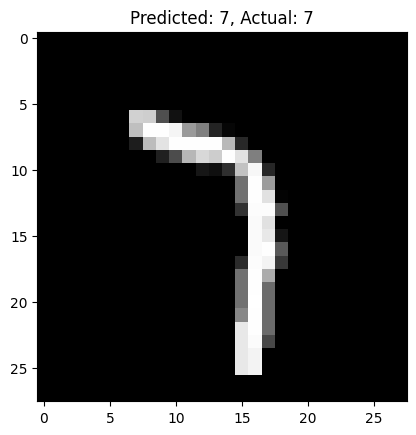

In [14]:
import matplotlib.pyplot as plt

image, label = test_dataset[122]

with torch.no_grad():
    output = model(image.unsqueeze(0))
    pred = torch.argmax(output, dim=1)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Predicted: {pred.item()}, Actual: {label}")
plt.show()


In [ ]:
28x28 Image → Flatten (784)
        ↓
Dense Layer (256) + ReLU
        ↓
Dense Layer (128) + ReLU
        ↓
Output Layer (10 classes)
